# Artefact A — Gas Measurement Analysis
Reads `gas-results.json` generated by `npx hardhat test` and loads data into pandas DataFrames for analysis.

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw data
with open('gas-results.json') as f:
    data = json.load(f)

print(f"Artefact: {data['artefact']}")
print(f"Scenario: {data['scenario']}")
print(f"Description: {data['description']}")
print(f"Timestamp: {data['timestamp']}")

Artefact: A
Scenario: 1
Description: Conventional smart contracts — fungible token, quarterly distribution
Timestamp: 2026-05-04T08:08:05.658Z


## 1. Distribution Gas DataFrame (DO3 / DO6)

In [3]:
df_dist = pd.DataFrame(data['distribution'])
df_dist.columns = ['investors', 'total_gas', 'gas_per_investor']
df_dist

,investors,total_gas,gas_per_investor
0,1,62245,62245
1,5,138629,27726
2,10,234113,23411
3,20,425106,21255
4,50,998070,19961
5,100,1953057,19531
6,200,3863101,19316
7,400,7683705,19209
8,800,15326777,19158


## 2. Onboarding Gas DataFrame (DO1 / DO2)

In [4]:
df_onboard = pd.DataFrame(data['onboarding'])
df_onboard.columns = ['investors', 'avg_register_gas', 'avg_mint_gas', 'avg_total_gas']
df_onboard

,investors,avg_register_gas,avg_mint_gas,avg_total_gas
0,1,49274,72420,121694
1,5,49272,58738,108010
2,10,49272,57028,106300
3,20,49273,56174,105447
4,50,49273,55661,104934
5,100,49273,55490,104763
6,200,49273,55405,104678
7,400,49273,55362,104635
8,800,49273,55341,104614


## 3. Linear Regression on Distribution Gas

In [5]:
from numpy.polynomial import polynomial as P

x = df_dist['investors'].values
y = df_dist['total_gas'].values

# Linear regression: y = slope * x + intercept
coeffs = np.polyfit(x, y, 1)
slope     = coeffs[0]
intercept = coeffs[1]

# R-squared
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Slope (marginal gas per investor): {slope:,.1f} gas")
print(f"Intercept (fixed overhead):        {intercept:,.1f} gas")
print(f"R²:                                {r2:.6f}")

# Add fitted values and residuals to df
df_dist['fitted_gas']   = (slope * df_dist['investors'] + intercept).round().astype(int)
df_dist['residual']     = df_dist['total_gas'] - df_dist['fitted_gas']
df_dist['residual_pct'] = (df_dist['residual'] / df_dist['total_gas'] * 100).round(3)
df_dist

Slope (marginal gas per investor): 19,104.2 gas
Intercept (fixed overhead):        42,834.5 gas
R²:                                1.000000


,investors,total_gas,gas_per_investor,fitted_gas,residual,residual_pct
0,1,62245,62245,61939,306,0.492
1,5,138629,27726,138356,273,0.197
2,10,234113,23411,233877,236,0.101
3,20,425106,21255,424919,187,0.044
4,50,998070,19961,998045,25,0.003
5,100,1953057,19531,1953256,-199,-0.010
6,200,3863101,19316,3863678,-577,-0.015
7,400,7683705,19209,7684522,-817,-0.011
8,800,15326777,19158,15326210,567,0.004


## 4. Extrapolation to 1,000 and 10,000 Investors

In [6]:
ext_counts = [1000, 10000]
ext_gas    = [int(slope * n + intercept) for n in ext_counts]
ext_gpi    = [int(g / n) for n, g in zip(ext_counts, ext_gas)]

df_ext = pd.DataFrame({
    'investors':        ext_counts,
    'total_gas':        ext_gas,
    'gas_per_investor': ext_gpi,
    'source':           ['extrapolated', 'extrapolated']
})

print("Extrapolated values (from linear regression model):")
df_ext

Extrapolated values (from linear regression model):


,investors,total_gas,gas_per_investor,source
0,1000,19147054,19147,extrapolated
1,10000,191085031,19108,extrapolated


## 5. Combined Distribution Table (empirical + extrapolated)

In [7]:
df_dist['source'] = 'empirical'

df_combined = pd.concat([
    df_dist[['investors', 'total_gas', 'gas_per_investor', 'source']],
    df_ext
], ignore_index=True)

df_combined

,investors,total_gas,gas_per_investor,source
0,1,62245,62245,empirical
1,5,138629,27726,empirical
2,10,234113,23411,empirical
3,20,425106,21255,empirical
4,50,998070,19961,empirical
5,100,1953057,19531,empirical
6,200,3863101,19316,empirical
7,400,7683705,19209,empirical
8,800,15326777,19158,empirical
9,1000,19147054,19147,extrapolated


## 6. Lifetime Cost per Investor (DO6)

In [8]:
# Parameters — adjust as needed
gas_price_gwei = 30          # gwei per gas unit
eth_eur        = 3200        # EUR per ETH
distributions  = 80          # quarterly over 20 years

gas_price_eth = gas_price_gwei * 1e-9  # convert gwei to ETH

onboard_gas   = df_onboard.iloc[-1]['avg_total_gas']   # at scale (800 investors)
dist_gas_each = df_dist.iloc[-1]['gas_per_investor']   # marginal gas per investor per distribution

lifetime_gas  = onboard_gas + (dist_gas_each * distributions)
lifetime_eur  = lifetime_gas * gas_price_eth * eth_eur

print(f"Onboarding gas (register + mint):    {onboard_gas:,} gas")
print(f"Distribution gas per investor:        {dist_gas_each:,} gas")
print(f"Number of distributions (20yr):       {distributions}")
print(f"Lifetime gas per investor:            {lifetime_gas:,} gas")
print(f"Lifetime cost per investor (EUR):     €{lifetime_eur:.4f}")
print(f"  (at {gas_price_gwei} gwei, ETH/EUR = {eth_eur})")

Onboarding gas (register + mint):    104,614 gas
Distribution gas per investor:        19,158 gas
Number of distributions (20yr):       80
Lifetime gas per investor:            1,637,254 gas
Lifetime cost per investor (EUR):     €157.1764
  (at 30 gwei, ETH/EUR = 3200)


## 7. Plots

### Plot 1A — Total Distribution Gas (empirical + extrapolated + regression line)

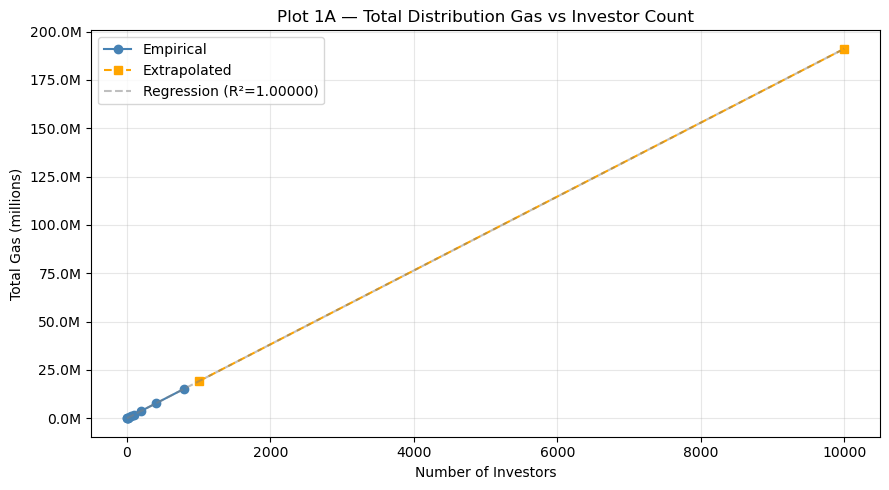

Saved: plot1a_distribution_gas_full.png


In [12]:
emp = df_dist[df_dist['source'] == 'empirical']

fig, ax = plt.subplots(figsize=(9, 5))

fit_x = np.linspace(0, 10000, 200)
fit_y = (slope * fit_x + intercept) / 1_000_000

ax.plot(emp['investors'], emp['total_gas'] / 1_000_000,
        'o-', color='steelblue', label='Empirical')
ax.plot(df_ext['investors'], df_ext['total_gas'] / 1_000_000,
        's--', color='orange', label='Extrapolated')
ax.plot(fit_x, fit_y,
        '--', color='grey', alpha=0.5, label=f'Regression (R\u00b2={r2:.5f})')

ax.set_title('Plot 1A \u2014 Total Distribution Gas vs Investor Count')
ax.set_xlabel('Number of Investors')
ax.set_ylabel('Total Gas (millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}M'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1a_distribution_gas_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot1a_distribution_gas_full.png')

### Plot 1B — Total Distribution Gas (empirical only)

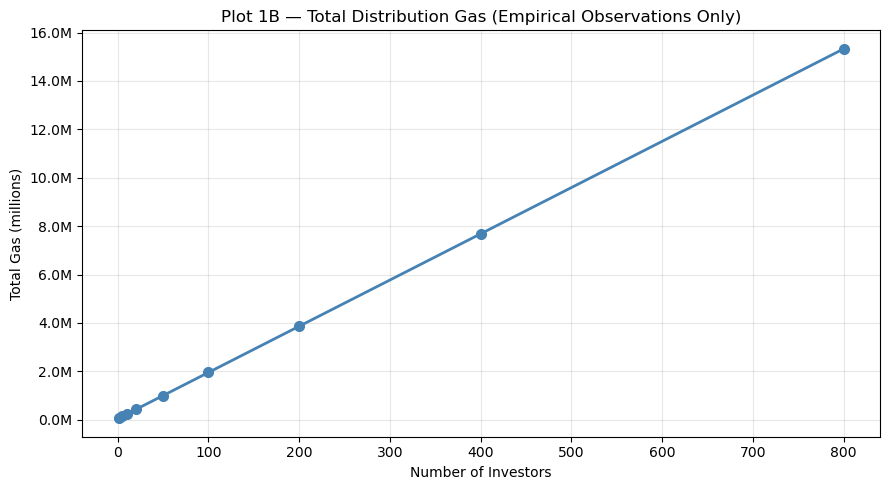

Saved: plot1b_distribution_gas_empirical.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(emp['investors'], emp['total_gas'] / 1_000_000,
        'o-', color='steelblue', linewidth=2, markersize=7)

ax.set_title('Plot 1B \u2014 Total Distribution Gas (Empirical Observations Only)')
ax.set_xlabel('Number of Investors')
ax.set_ylabel('Total Gas (millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1b_distribution_gas_empirical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot1b_distribution_gas_empirical.png')

### ZOOM BELOW

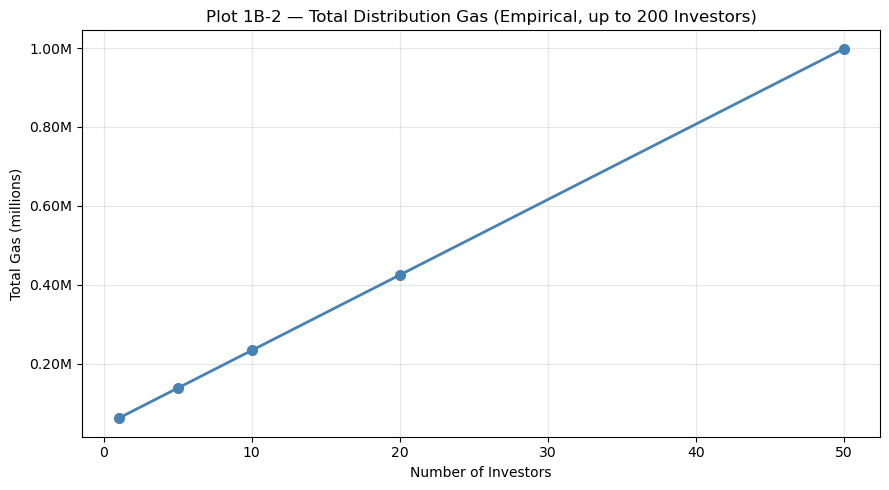

Saved: plot1b2_distribution_gas_zoom.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 5))

emp_zoom = emp[emp['investors'] <= 50] # Change this one to zoom in on the gas numbers. 

ax.plot(emp_zoom['investors'], emp_zoom['total_gas'] / 1_000_000,
        'o-', color='steelblue', linewidth=2, markersize=7)

ax.set_title('Plot 1B-2 \u2014 Total Distribution Gas (Empirical, up to 200 Investors)')
ax.set_xlabel('Number of Investors')
ax.set_ylabel('Total Gas (millions)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}M'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1b2_distribution_gas_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot1b2_distribution_gas_zoom.png')

### Plot 2 — Distribution Gas per Investor

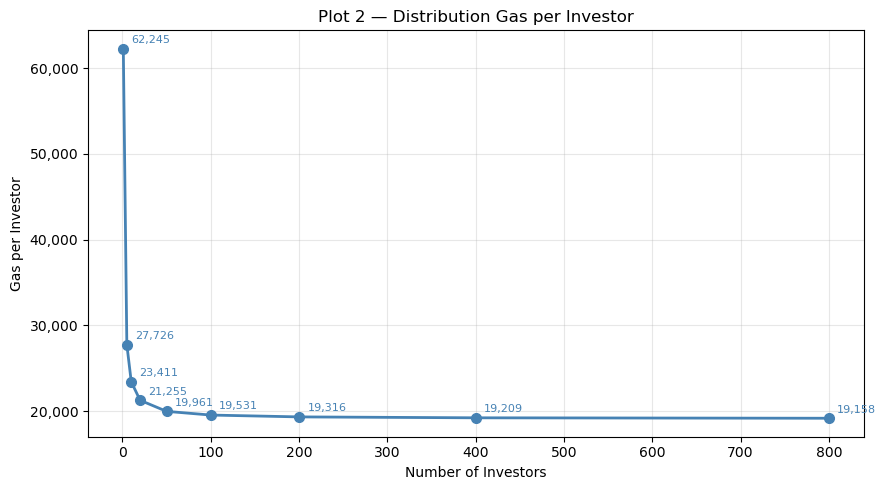

Saved: plot2_gas_per_investor.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(emp['investors'], emp['gas_per_investor'],
        'o-', color='steelblue', linewidth=2, markersize=7)

for _, row in emp.iterrows():
    ax.annotate(f"{int(row['gas_per_investor']):,}",
                xy=(row['investors'], row['gas_per_investor']),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8, color='steelblue')

ax.set_title('Plot 2 \u2014 Distribution Gas per Investor')
ax.set_xlabel('Number of Investors')
ax.set_ylabel('Gas per Investor')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_gas_per_investor.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot2_gas_per_investor.png')

### Plot 3 — Onboarding Gas Breakdown (Register vs Mint)

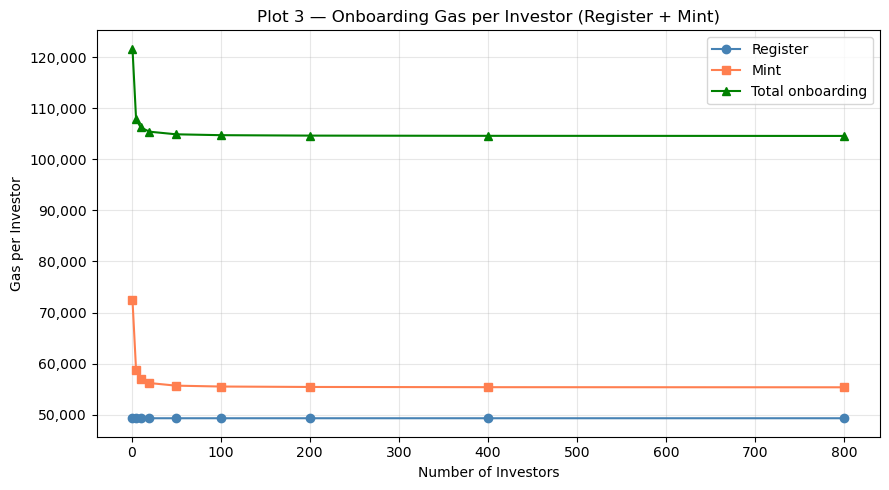

Saved: plot3_onboarding_gas.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_onboard['investors'], df_onboard['avg_register_gas'],
        'o-', color='steelblue', label='Register')
ax.plot(df_onboard['investors'], df_onboard['avg_mint_gas'],
        's-', color='coral', label='Mint')
ax.plot(df_onboard['investors'], df_onboard['avg_total_gas'],
        '^-', color='green', label='Total onboarding')

ax.set_title('Plot 3 \u2014 Onboarding Gas per Investor (Register + Mint)')
ax.set_xlabel('Number of Investors')
ax.set_ylabel('Gas per Investor')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot3_onboarding_gas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot3_onboarding_gas.png')